# PFS x DESI Multi-Tracer Fisher Forecast — Figures

This notebook reproduces all five figures from the Fisher forecast pipeline
and explains the physical meaning of each plot.

**Scientific context:** We use the ~1,200 deg² overlap between PFS-ELG and
DESI-ELG at 0.8 < z < 1.6 to cross-calibrate EFT nuisance parameters
(counterterms and stochastic terms). The calibrated priors are then exported
to DESI's full 14,000 deg² footprint. The key question: how much do
cosmological constraints (fσ₈, Mν, Ωm) improve compared to using
conservative broad priors?

**Four analysis scenarios:**
- **Broad**: conservative Gaussian priors from Chudaykin+ 2025
- **Cross-cal**: priors calibrated from the PFS×DESI overlap (kmax = 0.20 h/Mpc)
- **Cross-cal-ext**: same calibrated priors, extended kmax = 0.25 h/Mpc
- **Oracle**: nuisance parameters perfectly known (theoretical ceiling)

**Asymmetric kmax:** PFS has lower FoG (finger-of-god) contamination than DESI,
so the EFT expansion converges to higher k for PFS. In the overlap calibration,
we use kmax_PFS > kmax_DESI, derived from the FoG velocity ratio:
kmax_PFS = kmax_DESI × r_σv^{-1/2}.

In [1]:
import os, sys
os.chdir("/Users/nguyenmn/PFSxDESI-multi-fish")
sys.path.insert(0, ".")

import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Run the pipeline (takes ~30-60s)
from pfsfog.config import ForecastConfig
from pfsfog.cli import run_pipeline

cfg = ForecastConfig.from_yaml("configs/default.yaml")
results = run_pipeline(cfg, verbose=True)

Output → results/20260420_161144



=== Step 1: Overlap calibration ===
  Asymmetric kmax: DESI=0.200, PFS=0.231, cross=0.231 h/Mpc
  k_low: 39 bins to 0.200, k_high: 6 bins to 0.230
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.


Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.


  z=[0.8,1.0]: σ_cal(c_tilde)=368.9  σ_cal(Pshot)=0.442


  z=[1.0,1.2]: σ_cal(c_tilde)=368.9  σ_cal(Pshot)=0.269


...

  z=[1.4,1.6]: σ_cal(c_tilde)=390.1  σ_cal(Pshot)=0.152

=== Step 2: Full-area DESI Fisher ===

  Scenario: broad (kmax=0.2)


    σ(fsigma8) = 7.5652e-02  (improvement: +0.0%)
    σ(Mnu) = 1.0750e+00  (improvement: +0.0%)
    σ(Omegam) = 4.9856e-02  (improvement: +0.0%)

  Scenario: cross-cal (kmax=0.2)


    σ(fsigma8) = 6.0995e-02  (improvement: +19.4%)
    σ(Mnu) = 5.5894e-01  (improvement: +48.0%)
    σ(Omegam) = 4.0149e-02  (improvement: +19.5%)

  Scenario: cross-cal-ext (kmax=0.25)


    σ(fsigma8) = 4.9258e-02  (improvement: +34.9%)
    σ(Mnu) = 5.0509e-01  (improvement: +53.0%)
    σ(Omegam) = 3.8808e-02  (improvement: +22.2%)

  Scenario: oracle (kmax=0.25)


    σ(fsigma8) = 1.0005e-02  (improvement: +86.8%)
    σ(Mnu) = 1.2272e-01  (improvement: +88.6%)
    σ(Omegam) = 1.9395e-02  (improvement: +61.1%)

Summary written to results/20260420_161144/summary.csv


In [2]:
# ---------- Plot style (serif, Computer Modern, >= 14pt) ----------
def set_style():
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 12,
        "figure.dpi": 150,
        "axes.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "text.usetex": False,
    })

set_style()

# Convenient references
overlap = results.overlap_results        # {(zlo,zhi): OverlapResult}
scenarios = results.scenario_results      # {"broad": ScenarioResult, ...}
z_bins = results.config.z_bins            # [(0.8,1.0), (1.0,1.2), ...]

from pfsfog.eft_params import broad_priors, NUISANCE_NAMES, HOD_BENCHMARK, FIELD_LEVEL_BENCHMARK
from pfsfog.scenarios import compute_calibration_efficiency

## Figure 1 — Overlap calibration: which nuisance parameters tighten?

**What this shows:** For each redshift bin, we compare the marginalized
uncertainty σ on selected DESI nuisance parameters from three analyses
in the 1,200 deg² overlap volume:
1. **DESI-only** (blue): single-tracer Fisher using only P^{BB} (DESI auto-spectrum)
2. **PFS-only** (orange): single-tracer Fisher using only P^{AA} (PFS auto-spectrum, extended to kmax_PFS)
3. **PFS×DESI** (green): multi-tracer Fisher using all three spectra (P^{AA}, P^{BB}, P^{AB})

**Axes:**
- **x-axis**: EFT nuisance parameter name (c̃ = FoG counterterm, c₀ = monopole counterterm, P_shot = shot noise departure from Poisson, a₀ = k²-dependent stochastic)
- **y-axis**: σ / σ_broad — the marginalized uncertainty normalized by the broad (conservative) prior width. A value of 1.0 means the data adds no information beyond the prior; lower values mean the data constrains the parameter.

**Interpretation:** The multi-tracer analysis (green) always provides the tightest constraint.
P_shot and a₀ benefit most because the cross-spectrum P^{AB} has zero stochastic contribution,
allowing clean separation of signal from shot noise. The counterterms (c̃, c₀) are harder to
constrain because the k⁴ and k² terms are small at the k-scales used. PFS-only (orange) does
better than DESI-only (blue) on c̃ because PFS reaches higher kmax (asymmetric kmax from lower FoG).

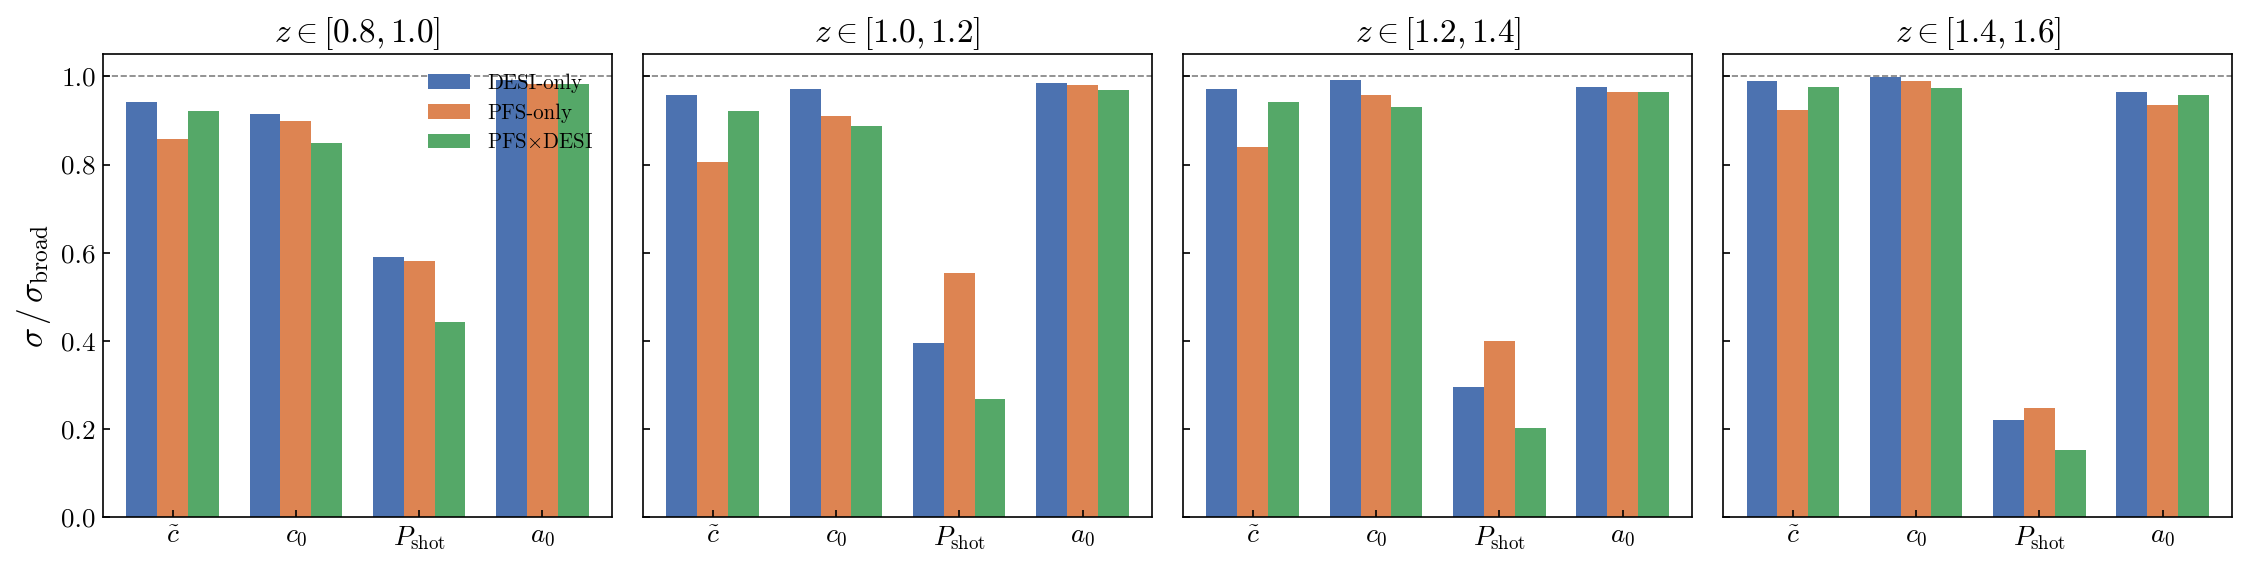

In [3]:
# ===== Figure 1: Overlap calibration =====
bp = broad_priors().sigma_dict()
params_to_plot = ["c_tilde", "c0", "Pshot", "a0"]
param_labels = [r"$\tilde{c}$", r"$c_0$", r"$P_{\rm shot}$", r"$a_0$"]

sorted_zbins = sorted(overlap.keys())
n_z = len(sorted_zbins)

fig, axes = plt.subplots(1, n_z, figsize=(3.8 * n_z, 4), sharey=True)
if n_z == 1:
    axes = [axes]

for iz, zb in enumerate(sorted_zbins):
    ax = axes[iz]
    ov = overlap[zb]
    x = np.arange(len(params_to_plot))
    w = 0.25
    norms = [bp[p] for p in params_to_plot]

    vals_desi = [ov.sigma_desi_only[p] / n for p, n in zip(params_to_plot, norms)]
    vals_pfs  = [ov.sigma_pfs_only[p]  / n for p, n in zip(params_to_plot, norms)]
    vals_mt   = [ov.sigma_mt[p]        / n for p, n in zip(params_to_plot, norms)]

    ax.bar(x - w, vals_desi, w, label="DESI-only",          color="#4C72B0")
    ax.bar(x,     vals_pfs,  w, label="PFS-only",           color="#DD8452")
    ax.bar(x + w, vals_mt,   w, label=r"PFS$\times$DESI",   color="#55A868")
    ax.axhline(1.0, ls="--", color="gray", lw=0.8, zorder=0)

    ax.set_xticks(x)
    ax.set_xticklabels(param_labels)
    ax.set_title(f"$z \\in [{zb[0]:.1f}, {zb[1]:.1f}]$")
    if iz == 0:
        ax.set_ylabel(r"$\sigma\,/\,\sigma_{\rm broad}$")
        ax.legend(frameon=False, fontsize=10)

fig.tight_layout()
plt.show()

## Figure 2 — Calibrated vs broad priors (all DESI nuisance parameters)

**What this shows:** For every DESI nuisance parameter that has a Gaussian prior,
we compare the broad (conservative) prior width σ_broad (light blue bars) to the
cross-calibrated prior width σ_cal (colored dots, one per z-bin) extracted from
the overlap multi-tracer Fisher.

**Axes:**
- **x-axis**: Parameter name in the Chudaykin+ 2025 EFT convention:
  b₂σ₈², bG₂σ₈² (nonlinear biases); bΓ₃ (cubic tidal bias);
  c₀, c₂, c₄ (leading counterterms, [Mpc/h]²); c̃ (FoG counterterm, [Mpc/h]⁴);
  c₁ (sub-leading counterterm, [Mpc/h]²); P_shot, a₀, a₂ (stochastic, dimensionless).
- **y-axis**: Prior width σ (log scale). Units vary by parameter (see x-axis).

**Interpretation:** Parameters whose dots sit well below the bar are substantially
tightened by the cross-calibration. P_shot shows the most dramatic improvement
(from σ=1 down to ~0.15–0.45). The counterterms (c₀, c₂, c₄, c̃) barely move —
the overlap data at k ≤ 0.23 h/Mpc provides little information on these k²/k⁴ terms.
b₂σ₈² and bG₂σ₈² show modest tightening from the one-loop bias sensitivity.

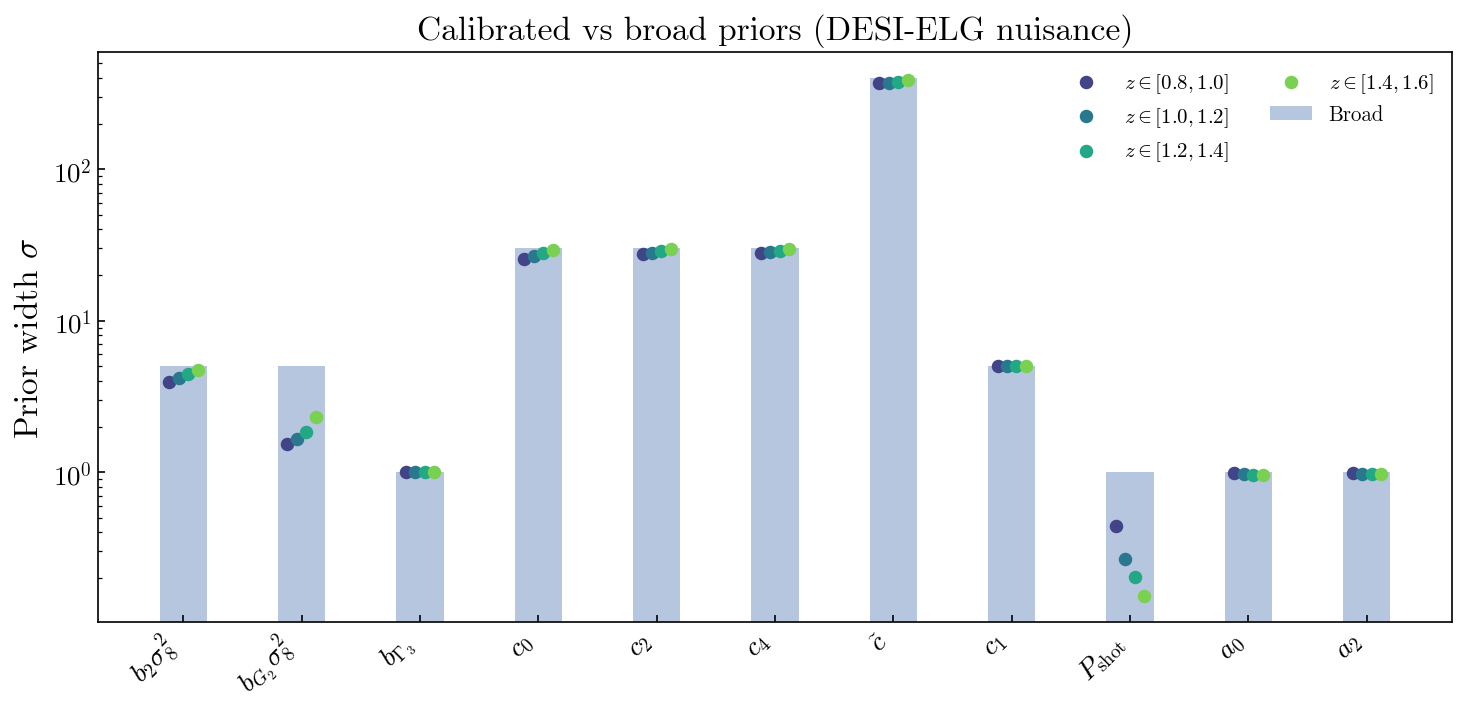

In [4]:
# ===== Figure 2: Calibrated vs broad priors =====
bp_dict = broad_priors().sigma_dict()
params_with_prior = [n for n in NUISANCE_NAMES if bp_dict[n] is not None]

plabels = {
    "b2_sigma8sq": r"$b_2\sigma_8^2$", "bG2_sigma8sq": r"$b_{G_2}\sigma_8^2$",
    "bGamma3": r"$b_{\Gamma_3}$", "c0": r"$c_0$", "c2": r"$c_2$", "c4": r"$c_4$",
    "c_tilde": r"$\tilde{c}$", "c1": r"$c_1$",
    "Pshot": r"$P_{\rm shot}$", "a0": r"$a_0$", "a2": r"$a_2$",
}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(params_with_prior))
broad_vals = [bp_dict[p] for p in params_with_prior]
ax.bar(x, broad_vals, 0.4, label="Broad", color="#4C72B0", alpha=0.4)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_zbins)))
for iz, zb in enumerate(sorted_zbins):
    cal = overlap[zb].calibrated_priors
    cal_vals = [cal.params[p] for p in params_with_prior]
    offset = (iz - len(sorted_zbins) / 2 + 0.5) * 0.08
    ax.scatter(x + offset, cal_vals, color=colors[iz], s=30, zorder=5,
               label=f"$z \\in [{zb[0]:.1f},{zb[1]:.1f}]$")

ax.set_xticks(x)
ax.set_xticklabels([plabels.get(p, p) for p in params_with_prior],
                    rotation=45, ha="right")
ax.set_ylabel(r"Prior width $\sigma$")
ax.set_yscale("log")
ax.legend(frameon=False, fontsize=10, ncol=2)
ax.set_title("Calibrated vs broad priors (DESI-ELG nuisance)")
fig.tight_layout()
plt.show()

## Figure 3 — Full-area DESI constraints (money figure)

**What this shows:** The marginalized 1σ uncertainty on three cosmological
parameters from the full DESI-ELG footprint (14,000 deg², combined z-bins),
under each of the four analysis scenarios. Horizontal dashed/dotted lines
show published benchmark improvements from alternative approaches.

**Axes:**
- **x-axis**: Analysis scenario (Broad, Cross-cal, Cross-cal-ext, Oracle).
- **y-axis**: Marginalized σ on the cosmological parameter.
  - Left panel: σ(fσ₈) — dimensionless (fσ₈ ≈ 0.47 at z~1).
  - Center panel: σ(Mν) — neutrino mass sum in eV.
  - Right panel: σ(Ωm) — dimensionless matter density fraction.

**Benchmark lines (left panel):**
- **HOD-prior (23%)**: Zhang+ 2025 — HOD-informed priors from 320k AbacusSummit mocks improve σ(σ₈) by 23% over broad priors. Fair comparison (both at power-spectrum level).
- **Field-level (50%)**: Chudaykin+ 2026 — field-level simulation-based priors improve σ(σ₈) by 50%. Ceiling (breaks degeneracies inaccessible to 2pt).

**Interpretation:** The cross-calibration (orange) already exceeds the HOD-prior
benchmark for fσ₈. With extended kmax (green), the improvement reaches ~35%.
The gap to the oracle (red) shows remaining room — primarily from counterterm
parameters that the overlap volume cannot constrain at the available k-scales.

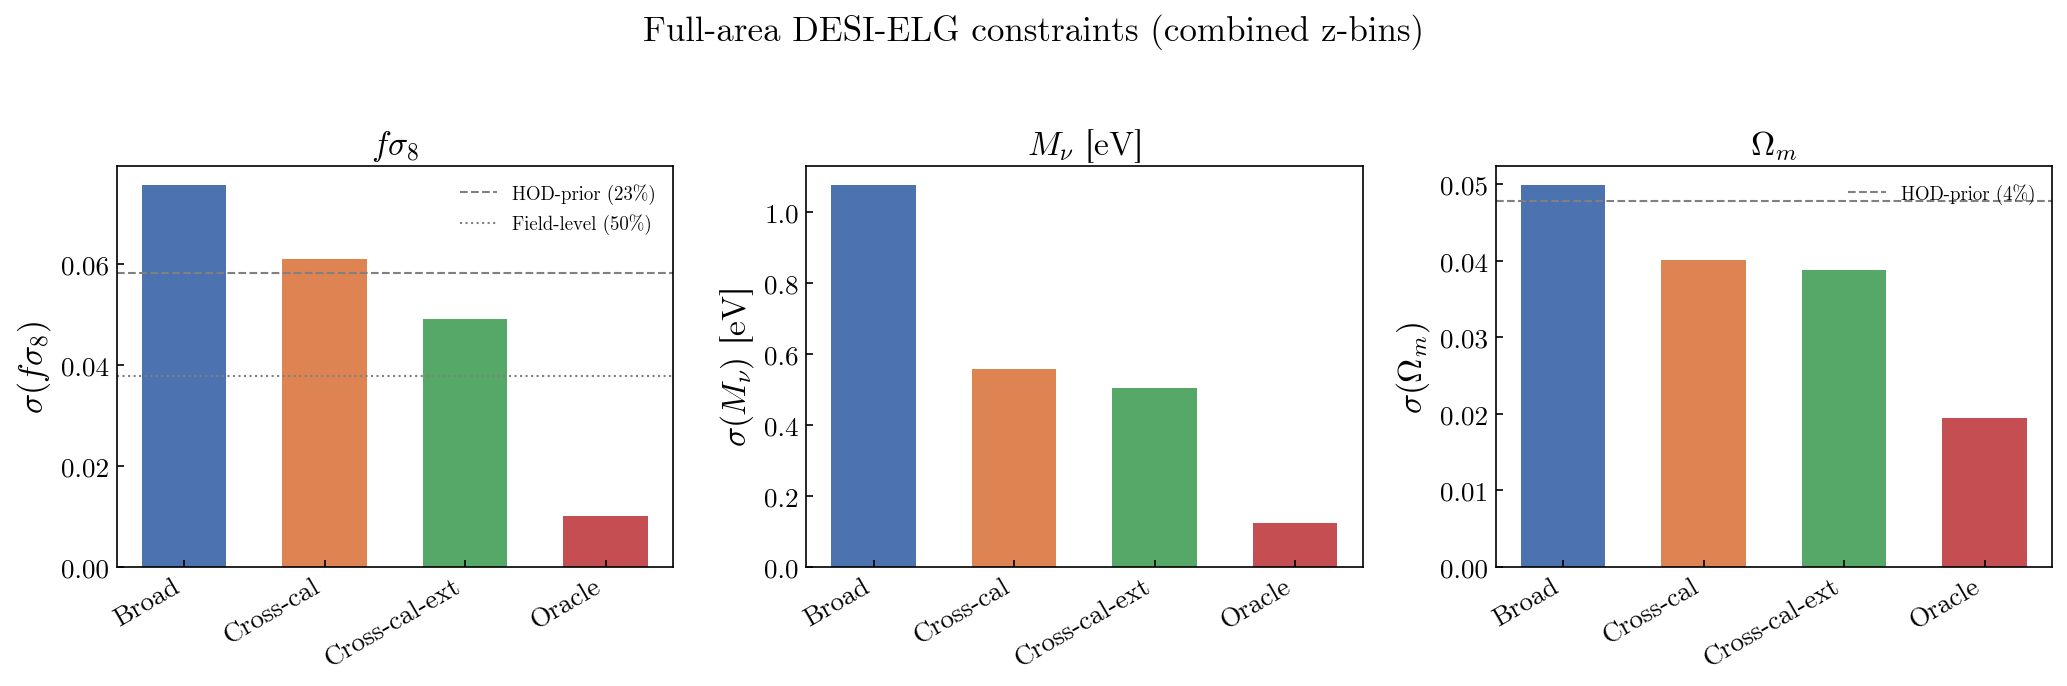


Headline numbers:
  $f\sigma_8$   Broad           : σ = 7.5652e-02  (+0.0%)
  $f\sigma_8$   Cross-cal       : σ = 6.0995e-02  (+19.4%)
  $f\sigma_8$   Cross-cal-ext   : σ = 4.9258e-02  (+34.9%)
  $f\sigma_8$   Oracle          : σ = 1.0005e-02  (+86.8%)
  $M_\nu$ [eV]  Broad           : σ = 1.0750e+00  (+0.0%)
  $M_\nu$ [eV]  Cross-cal       : σ = 5.5894e-01  (+48.0%)
  $M_\nu$ [eV]  Cross-cal-ext   : σ = 5.0509e-01  (+53.0%)
  $M_\nu$ [eV]  Oracle          : σ = 1.2272e-01  (+88.6%)
  $\Omega_m$    Broad           : σ = 4.9856e-02  (+0.0%)
  $\Omega_m$    Cross-cal       : σ = 4.0149e-02  (+19.5%)
  $\Omega_m$    Cross-cal-ext   : σ = 3.8808e-02  (+22.2%)
  $\Omega_m$    Oracle          : σ = 1.9395e-02  (+61.1%)


In [5]:
# ===== Figure 3: Full-area DESI constraints =====
from pfsfog.scenarios import SCENARIOS

cosmo_params = ["fsigma8", "Mnu", "Omegam"]
param_titles = [r"$f\sigma_8$", r"$M_\nu$ [eV]", r"$\Omega_m$"]
param_ylabels = [r"$\sigma(f\sigma_8)$", r"$\sigma(M_\nu)$ [eV]", r"$\sigma(\Omega_m)$"]
scenario_names = [s.name for s in SCENARIOS]

COLORS = {"broad": "#4C72B0", "cross-cal": "#DD8452",
          "cross-cal-ext": "#55A868", "oracle": "#C44E52"}
LABELS = {"broad": "Broad", "cross-cal": "Cross-cal",
          "cross-cal-ext": "Cross-cal-ext", "oracle": "Oracle"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ip, (cp, title, ylabel) in enumerate(zip(cosmo_params, param_titles, param_ylabels)):
    ax = axes[ip]
    x = np.arange(len(scenario_names))
    vals = [scenarios[sn].sigmas_combined[cp] for sn in scenario_names]
    colors = [COLORS[sn] for sn in scenario_names]

    ax.bar(x, vals, color=colors, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS[sn] for sn in scenario_names], rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    sigma_broad = scenarios["broad"].sigmas_combined[cp]
    if cp == "fsigma8":
        ax.axhline(sigma_broad * (1 - HOD_BENCHMARK["sigma8_improvement"]),
                   ls="--", color="gray", lw=1, label=f"HOD-prior (23%)")
        ax.axhline(sigma_broad * (1 - FIELD_LEVEL_BENCHMARK["sigma8_improvement"]),
                   ls=":", color="gray", lw=1, label=f"Field-level (50%)")
        ax.legend(frameon=False, fontsize=9)
    if cp == "Omegam":
        ax.axhline(sigma_broad * (1 - HOD_BENCHMARK["Omegam_improvement"]),
                   ls="--", color="gray", lw=1, label=f"HOD-prior (4%)")
        ax.legend(frameon=False, fontsize=9)

fig.suptitle("Full-area DESI-ELG constraints (combined z-bins)", y=1.02)
fig.tight_layout()
plt.show()

# Print the numbers
print("\nHeadline numbers:")
for cp, label in zip(cosmo_params, param_titles):
    sb = scenarios["broad"].sigmas_combined[cp]
    for sn in scenario_names:
        s = scenarios[sn].sigmas_combined[cp]
        imp = (sb - s) / sb * 100
        print(f"  {label:12s}  {LABELS[sn]:16s}: σ = {s:.4e}  ({imp:+.1f}%)")

## Figure 4 — Calibration efficiency per redshift bin

**What this shows:** How much of the gap between broad priors and perfect
(oracle) knowledge does the cross-calibration recover, in each z-bin?

**Definition:**

$$\text{efficiency} = \frac{\sigma_{\rm broad} - \sigma_{\rm cross\text{-}cal\text{-}ext}}{\sigma_{\rm broad} - \sigma_{\rm oracle}}$$

A value of 0 means the cross-calibration adds nothing beyond broad priors;
a value of 1 means it achieves the oracle limit.

**Axes:**
- **x-axis**: Effective redshift z_eff of each z-bin (volume-weighted midpoint).
- **y-axis**: Calibration efficiency (dimensionless, ∈ [0, 1]).

**Three lines:** fσ₈ (blue circles), Mν (orange squares), Ωm (green triangles).

**Interpretation:** Mν has the highest efficiency (~60%) because the neutrino
mass constraint is most sensitive to the stochastic parameters (P_shot, a₀)
that the cross-calibration tightens most. fσ₈ efficiency rises with z (~38→47%)
because PFS's nbar advantage grows at higher z. Ωm efficiency is flat (~35%)
and lower because Ωm is mainly constrained by the shape of P(k), not the
amplitude-related nuisance parameters.

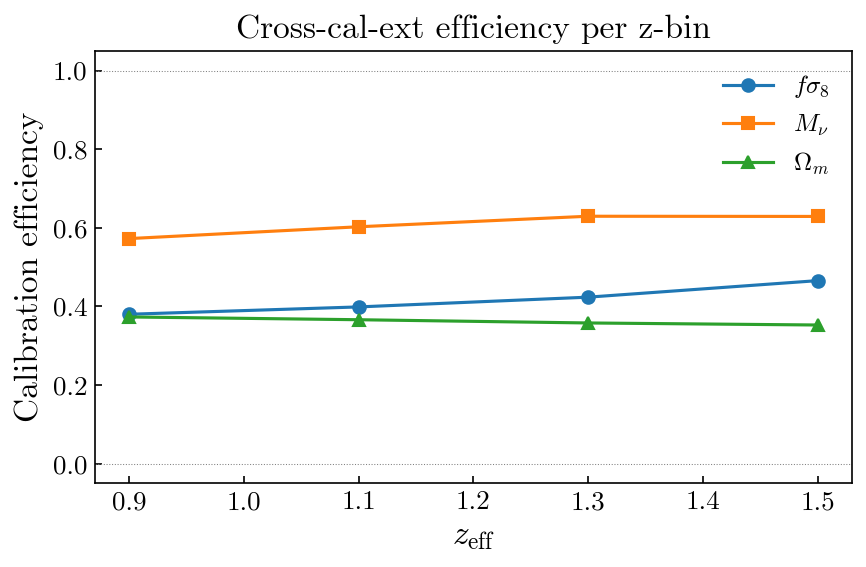


Calibration efficiency (cross-cal-ext):
  $f\sigma_8$   z=0.90: eff = 0.380
  $f\sigma_8$   z=1.10: eff = 0.399
  $f\sigma_8$   z=1.30: eff = 0.424
  $f\sigma_8$   z=1.50: eff = 0.466
  $M_\nu$       z=0.90: eff = 0.573
  $M_\nu$       z=1.10: eff = 0.603
  $M_\nu$       z=1.30: eff = 0.630
  $M_\nu$       z=1.50: eff = 0.629
  $\Omega_m$    z=0.90: eff = 0.373
  $\Omega_m$    z=1.10: eff = 0.366
  $\Omega_m$    z=1.30: eff = 0.358
  $\Omega_m$    z=1.50: eff = 0.353


In [6]:
# ===== Figure 4: Calibration efficiency =====
fig, ax = plt.subplots(figsize=(6, 4))

markers = {"fsigma8": "o", "Mnu": "s", "Omegam": "^"}
labels  = {"fsigma8": r"$f\sigma_8$", "Mnu": r"$M_\nu$", "Omegam": r"$\Omega_m$"}

z_mids = [0.5 * (zb[0] + zb[1]) for zb in z_bins]

for cp in cosmo_params:
    effs = []
    for zb in z_bins:
        sb = scenarios["broad"].sigmas_per_z[zb][cp]
        so = scenarios["oracle"].sigmas_per_z[zb][cp]
        sx = scenarios["cross-cal-ext"].sigmas_per_z[zb][cp]
        eff = compute_calibration_efficiency(sx, sb, so)
        effs.append(eff if eff is not None else 0.0)
    ax.plot(z_mids, effs, marker=markers[cp], label=labels[cp], lw=1.5)

ax.set_xlabel(r"$z_{\rm eff}$")
ax.set_ylabel("Calibration efficiency")
ax.set_ylim(-0.05, 1.05)
ax.axhline(1.0, ls=":", color="gray", lw=0.5)
ax.axhline(0.0, ls=":", color="gray", lw=0.5)
ax.legend(frameon=False)
ax.set_title("Cross-cal-ext efficiency per z-bin")
fig.tight_layout()
plt.show()

# Print the numbers
print("\nCalibration efficiency (cross-cal-ext):")
for cp in cosmo_params:
    for zb, zm in zip(z_bins, z_mids):
        sb = scenarios["broad"].sigmas_per_z[zb][cp]
        so = scenarios["oracle"].sigmas_per_z[zb][cp]
        sx = scenarios["cross-cal-ext"].sigmas_per_z[zb][cp]
        eff = compute_calibration_efficiency(sx, sb, so)
        print(f"  {labels[cp]:12s}  z={zm:.2f}: eff = {eff:.3f}" if eff else f"  {labels[cp]:12s}  z={zm:.2f}: N/A")

## Figure 5 — Sensitivity to FoG velocity ratio r_σv

**What this shows:** How the combined σ(fσ₈) from the cross-cal-ext scenario
depends on the assumed FoG velocity ratio r_σv = σ_{v,PFS} / σ_{v,DESI}.

This parameter controls two things simultaneously:
1. **PFS FoG fiducial**: c̃_PFS = c̃_DESI × r_σv² — lower r_σv means PFS has weaker FoG.
2. **Asymmetric kmax**: kmax_PFS = kmax_DESI × r_σv^{−1/2} — lower r_σv allows
   PFS to reach higher k where the FoG counterterm contributes more.

**Axes:**
- **x-axis**: r_σv = σ_{v,PFS} / σ_{v,DESI} (dimensionless, ∈ [0.5, 1.0]).
  r_σv = 1 means identical FoG; r_σv = 0.5 means PFS has half the velocity dispersion.
- **y-axis**: σ(fσ₈) combined across z-bins (dimensionless).

**Reference lines:**
- **Broad baseline** (blue dashed): σ(fσ₈) with conservative broad priors.
- **10% improvement** (gray dotted): 90% of the broad baseline.

**Interpretation:** The curve slopes downward — lower r_σv gives tighter constraints,
confirming the asymmetric-kmax mechanism works. The improvement ranges from ~34%
(r_σv = 1, no FoG advantage) to ~39% (r_σv = 0.5, maximum FoG leverage).
Even at r_σv = 1.0, the improvement is substantial (~34%), because the dominant
contribution comes from stochastic parameter separation (P_shot, a₀) which
does not depend on r_σv. The additional ~5% from FoG is the asymmetric-kmax bonus.

**Note:** This sweep re-runs the full pipeline for each r_σv value (~30s each).
Adjust `r_values` below to add more points or narrow the range.

  r_σv = 0.50: σ(fσ₈) = 4.6152e-02  (improvement: 39.0%)


  r_σv = 0.60: σ(fσ₈) = 4.7792e-02  (improvement: 36.8%)


  r_σv = 0.75: σ(fσ₈) = 4.9258e-02  (improvement: 34.9%)


  r_σv = 0.90: σ(fσ₈) = 4.9882e-02  (improvement: 34.1%)


  r_σv = 1.00: σ(fσ₈) = 5.0106e-02  (improvement: 33.8%)


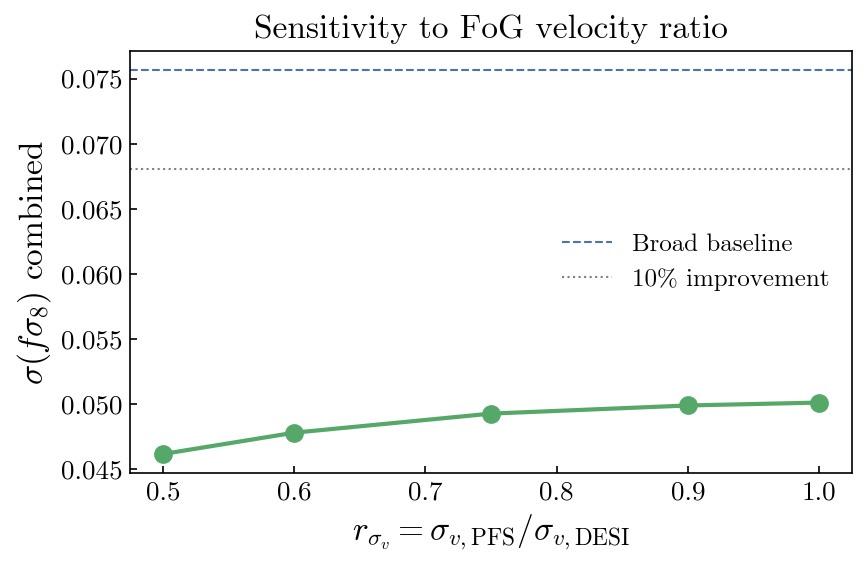

In [7]:
# ===== Figure 5: Sensitivity to r_sigma_v =====
# --- Sweep (re-runs pipeline for each r_σv; ~30s each) ---
r_values = [0.5, 0.6, 0.75, 0.9, 1.0]
sigma_fsigma8 = {}
broad_baseline = None

for r in r_values:
    cfg_r = ForecastConfig(r_sigma_v=r, output_dir="results/_sweep_rsv")
    res_r = run_pipeline(cfg_r, verbose=False)
    sigma_fsigma8[r] = res_r.scenario_results["cross-cal-ext"].sigmas_combined["fsigma8"]
    if broad_baseline is None:
        broad_baseline = res_r.scenario_results["broad"].sigmas_combined["fsigma8"]
    print(f"  r_σv = {r:.2f}: σ(fσ₈) = {sigma_fsigma8[r]:.4e}  "
          f"(improvement: {(broad_baseline - sigma_fsigma8[r]) / broad_baseline * 100:.1f}%)")

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 4))

r_arr = sorted(sigma_fsigma8.keys())
s_arr = [sigma_fsigma8[r] for r in r_arr]

ax.plot(r_arr, s_arr, "o-", color="#55A868", lw=2, ms=8)
ax.axhline(broad_baseline, ls="--", color="#4C72B0", lw=1, label="Broad baseline")
ax.axhline(broad_baseline * 0.9, ls=":", color="gray", lw=1, label="10% improvement")

ax.set_xlabel(r"$r_{\sigma_v} = \sigma_{v,\mathrm{PFS}} / \sigma_{v,\mathrm{DESI}}$")
ax.set_ylabel(r"$\sigma(f\sigma_8)$ combined")
ax.legend(frameon=False)
ax.set_title("Sensitivity to FoG velocity ratio")
fig.tight_layout()
plt.show()

## Summary table

Print all headline results in a single table for easy reference.

In [8]:
# ===== Summary table =====
print(f"{'Scenario':<18s} {'kmax':>5s}  {'σ(fσ8)':>10s}  {'Δ%':>6s}  "
      f"{'σ(Mν)':>10s}  {'Δ%':>6s}  {'σ(Ωm)':>10s}  {'Δ%':>6s}")
print("-" * 85)

sb = {cp: scenarios["broad"].sigmas_combined[cp] for cp in cosmo_params}

for sn in scenario_names:
    sc = [s for s in SCENARIOS if s.name == sn][0]
    row = f"{LABELS[sn]:<18s} {sc.kmax:5.2f}"
    for cp in cosmo_params:
        s = scenarios[sn].sigmas_combined[cp]
        imp = (sb[cp] - s) / sb[cp] * 100
        row += f"  {s:10.4e}  {imp:+5.1f}%"
    print(row)

print()
print(f"Asymmetric kmax: DESI = {cfg.kmax_desi_overlap:.3f}, "
      f"PFS = {cfg.compute_kmax_pfs():.3f} h/Mpc "
      f"(r_σv = {cfg.r_sigma_v})")
print(f"Overlap area: {cfg.overlap_area_deg2:.0f} deg²")
print(f"Full DESI area: {cfg.desi_area_deg2:.0f} deg²")
print(f"z-bins: {z_bins}")

Scenario            kmax      σ(fσ8)      Δ%       σ(Mν)      Δ%       σ(Ωm)      Δ%
-------------------------------------------------------------------------------------
Broad               0.20  7.5652e-02   +0.0%  1.0750e+00   +0.0%  4.9856e-02   +0.0%
Cross-cal           0.20  6.0995e-02  +19.4%  5.5894e-01  +48.0%  4.0149e-02  +19.5%
Cross-cal-ext       0.25  4.9258e-02  +34.9%  5.0509e-01  +53.0%  3.8808e-02  +22.2%
Oracle              0.25  1.0005e-02  +86.8%  1.2272e-01  +88.6%  1.9395e-02  +61.1%

Asymmetric kmax: DESI = 0.200, PFS = 0.231 h/Mpc (r_σv = 0.75)
Overlap area: 1200 deg²
Full DESI area: 14000 deg²
z-bins: [(0.8, 1.0), (1.0, 1.2), (1.2, 1.4), (1.4, 1.6)]
